# Model 1A, Calibration Experiment 01: CatBoost 04

This experiment calibrates the selected CatBoost Experiment 04 model without changing its 41-field manifest or fixed classifier configuration. It compares the uncalibrated probabilities with sigmoid (Platt-style) and isotonic corrections using only forward-chained held-out predictions from 2019. Mean temporal Brier score selects the method; a method-specific F1 threshold is also selected from 2019 only. The fixed choice is then evaluated once on 2023, and 2024 is never loaded.

Calibration is intended to improve probability reliability, not ranking. Sigmoid and isotonic calibration are therefore judged primarily by Brier score and log loss. No prediction file is written, and the retrospective final-tail assignment limitation remains.

In [1]:
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, f1_score, log_loss, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score,
)

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
FIXED_ITERATIONS = 683
FIXED_DEPTH = 6
FIXED_LEARNING_RATE = 0.03
FIXED_L2_LEAF_REG = 3
N_JOBS = 4
CALIBRATION_METHODS = ["Uncalibrated", "Sigmoid", "Isotonic"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost {catboost.__version__}")

CatBoost 1.2.10


## Pair and validate the three established feature paths

In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Reproduce CatBoost 04's selected manifest and temporal folds

In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
shared_numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
variant_features = {
    "CatBoost 02 control": [*categorical_features, *shared_numeric_features],
    "plus same-airline W60": [
        *categorical_features, *shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES
    ],
}
all_numeric_features = [*shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES]
required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET, *categorical_features, *all_numeric_features
]))
assert len(categorical_features) == 6 and len(shared_numeric_features) == 30
assert len(variant_features["CatBoost 02 control"]) == 36
assert len(variant_features["plus same-airline W60"]) == 41
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(set().union(*map(set, variant_features.values())))
pd.DataFrame({
    name: {"source fields": len(columns), "categorical": len(categorical_features),
           "numeric": len(columns) - len(categorical_features),
           "airport backlog fields": len([c for c in columns if c.startswith(BACKLOG_PREFIX)]),
           "airline backlog fields": len([c for c in columns if c.startswith(AIRLINE_BACKLOG_PREFIX)])}
    for name, columns in variant_features.items()
}).T


SELECTED_MANIFEST = "plus same-airline W60"
feature_columns = variant_features[SELECTED_MANIFEST]
assert len(feature_columns) == 41
print(f"Calibrating CatBoost 04 manifest: {len(feature_columns)} source fields")

Calibrating CatBoost 04 manifest: 41 source fields


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in all_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_variants = {
    name: train_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
X_validation_variants = {
    name: validation_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": train_model_df[all_numeric_features].isna().sum(),
    "validation_missing": validation_model_df[all_numeric_features].isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]


X_train = X_train_variants[SELECTED_MANIFEST]
X_validation = X_validation_variants[SELECTED_MANIFEST]

In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Generate CatBoost 04 held-out probabilities from 2019

In [7]:
def make_fixed_model(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=FIXED_ITERATIONS, loss_function="Logloss",
        eval_metric="PRAUC:type=Classic", depth=FIXED_DEPTH,
        learning_rate=FIXED_LEARNING_RATE, l2_leaf_reg=FIXED_L2_LEAF_REG,
        random_seed=seed, thread_count=N_JOBS, allow_writing_files=False,
        verbose=False,
    )

oof_probabilities = np.full(len(y_train), np.nan)
oof_fold = np.zeros(len(y_train), dtype=int)
base_fold_rows = []
oof_start = perf_counter()
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    model = make_fixed_model()
    model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx],
              cat_features=categorical_features, verbose=False)
    probabilities = model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
    oof_probabilities[heldout_idx] = probabilities
    oof_fold[heldout_idx] = fold_number
    base_fold_rows.append({
        "fold": fold_number,
        "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
        "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
        "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        "log_loss": log_loss(y_train.iloc[heldout_idx], probabilities),
    })
    print(f"Completed CatBoost 04 held-out fold {fold_number}/{N_TIME_SPLITS}")
print(f"Held-out fitting completed in {perf_counter() - oof_start:,.1f} seconds")
base_fold_results = pd.DataFrame(base_fold_rows).set_index("fold")
base_fold_results

Completed CatBoost 04 held-out fold 1/5


Completed CatBoost 04 held-out fold 2/5


Completed CatBoost 04 held-out fold 3/5


Completed CatBoost 04 held-out fold 4/5


Completed CatBoost 04 held-out fold 5/5
Held-out fitting completed in 72.4 seconds


,average_precision,roc_auc,brier_score,log_loss
fold,,,,
1,0.6620,0.8297,0.0905,0.3116
2,0.7381,0.8513,0.0968,0.3272
3,0.7905,0.8705,0.1069,0.3492
4,0.6404,0.8290,0.0764,0.2728
5,0.6778,0.8434,0.0873,0.3003


## Select calibration with forward-chained held-out 2019 predictions

In [8]:
def clipped(values):
    return np.clip(np.asarray(values, dtype=float), 1e-6, 1 - 1e-6)

def logit(values):
    values = clipped(values)
    return np.log(values / (1 - values))

def fit_calibrator(method, probabilities, targets):
    if method == "Uncalibrated":
        return None
    if method == "Sigmoid":
        calibrator = LogisticRegression(C=1e6, solver="lbfgs", random_state=RANDOM_STATE)
        calibrator.fit(logit(probabilities).reshape(-1, 1), np.asarray(targets))
        return calibrator
    if method == "Isotonic":
        calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
        calibrator.fit(np.asarray(probabilities), np.asarray(targets))
        return calibrator
    raise ValueError(method)

def apply_calibrator(method, calibrator, probabilities):
    if method == "Uncalibrated":
        return clipped(probabilities)
    if method == "Sigmoid":
        return calibrator.predict_proba(logit(probabilities).reshape(-1, 1))[:, 1]
    return clipped(calibrator.predict(np.asarray(probabilities)))

def expected_calibration_error(targets, probabilities, bins=10):
    frame = pd.DataFrame({"target": np.asarray(targets), "probability": probabilities})
    frame["bin"] = pd.qcut(frame["probability"], q=bins, duplicates="drop")
    grouped = frame.groupby("bin", observed=True).agg(
        rows=("target", "size"), observed=("target", "mean"), predicted=("probability", "mean")
    )
    return ((grouped["rows"] / len(frame)) * (grouped["observed"] - grouped["predicted"]).abs()).sum()

# Fold 1 supplies the first independent calibration rows. Each subsequent fold is
# assessed using a calibrator fitted only to earlier held-out folds.
forward_probabilities = {method: np.full(len(y_train), np.nan) for method in CALIBRATION_METHODS}
calibration_rows = []
for assessment_fold in range(2, N_TIME_SPLITS + 1):
    calibration_mask = (oof_fold > 0) & (oof_fold < assessment_fold)
    assessment_mask = oof_fold == assessment_fold
    for method in CALIBRATION_METHODS:
        calibrator = fit_calibrator(
            method, oof_probabilities[calibration_mask], y_train.to_numpy()[calibration_mask]
        )
        probabilities = apply_calibrator(method, calibrator, oof_probabilities[assessment_mask])
        forward_probabilities[method][assessment_mask] = probabilities
        targets = y_train.to_numpy()[assessment_mask]
        calibration_rows.append({
            "method": method, "fold": assessment_fold,
            "brier_score": brier_score_loss(targets, probabilities),
            "log_loss": log_loss(targets, probabilities),
            "average_precision": average_precision_score(targets, probabilities),
            "roc_auc": roc_auc_score(targets, probabilities),
            "ece_10": expected_calibration_error(targets, probabilities),
        })

calibration_fold_results = pd.DataFrame(calibration_rows)
calibration_summary = (calibration_fold_results.groupby("method", as_index=False)
    .agg(mean_brier_score=("brier_score", "mean"), mean_log_loss=("log_loss", "mean"),
         mean_ece_10=("ece_10", "mean"), mean_average_precision=("average_precision", "mean"),
         mean_roc_auc=("roc_auc", "mean"))
    .sort_values(["mean_brier_score", "mean_log_loss", "mean_ece_10"]))
selected_method = str(calibration_summary.iloc[0]["method"])
print(f"Selected calibration method: {selected_method}")
display(calibration_summary)
calibration_fold_results.pivot(index="fold", columns="method", values="brier_score")

Selected calibration method: Uncalibrated


,method,mean_brier_score,mean_log_loss,mean_ece_10,mean_average_precision,mean_roc_auc
2,Uncalibrated,0.0918,0.3124,0.0125,0.7117,0.8485
1,Sigmoid,0.0922,0.3137,0.0156,0.7117,0.8485
0,Isotonic,0.0923,0.3152,0.0160,0.7018,0.8479


method,Isotonic,Sigmoid,Uncalibrated
fold,,,
2,0.0985,0.0982,0.0968
3,0.1071,0.1068,0.1069
4,0.0763,0.0763,0.0764
5,0.0872,0.0872,0.0873


## Select method-specific operating thresholds from forward predictions

In [9]:
def classification_metrics(targets, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(targets, predictions),
        "precision": precision_score(targets, predictions, zero_division=0),
        "recall": recall_score(targets, predictions, zero_division=0),
        "f1": f1_score(targets, predictions, zero_division=0),
        "mcc": matthews_corrcoef(targets, predictions),
    }

method_thresholds = {}
threshold_rows = []
for method in dict.fromkeys(["Uncalibrated", selected_method]):
    probabilities = forward_probabilities[method]
    mask = np.isfinite(probabilities)
    targets = y_train.to_numpy()[mask]
    for threshold in np.round(np.arange(0.05, 0.801, 0.01), 2):
        threshold_rows.append({
            "method": method,
            **classification_metrics(targets, probabilities[mask], threshold),
        })
    method_rows = pd.DataFrame([row for row in threshold_rows if row["method"] == method])
    best = method_rows.sort_values(["f1", "balanced_accuracy", "precision"], ascending=False).iloc[0]
    method_thresholds[method] = float(best["threshold"])
    print(f"{method}: selected threshold {method_thresholds[method]:.2f}")
pd.DataFrame(threshold_rows).sort_values(["method", "f1"], ascending=[True, False]).groupby("method").head(5)

Uncalibrated: selected threshold 0.31


,method,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
26,Uncalibrated,0.3100,0.8730,0.7646,0.7042,0.5881,0.6410,0.5680
28,Uncalibrated,0.3300,0.8760,0.7609,0.7255,0.5736,0.6406,0.5726
27,Uncalibrated,0.3200,0.8744,0.7626,0.7142,0.5806,0.6405,0.5698
25,Uncalibrated,0.3000,0.8708,0.7660,0.6915,0.5955,0.6399,0.5641
29,Uncalibrated,0.3400,0.8771,0.7586,0.7357,0.5658,0.6397,0.5742


## Fit the final calibrator on held-out 2019 probabilities and evaluate once on 2023

In [10]:
oof_mask = np.isfinite(oof_probabilities)
final_calibrator = fit_calibrator(
    selected_method, oof_probabilities[oof_mask], y_train.to_numpy()[oof_mask]
)
final_model = make_fixed_model()
final_model.fit(X_train, y_train, cat_features=categorical_features, verbose=False)
raw_validation_probabilities = final_model.predict_proba(X_validation)[:, 1]
selected_validation_probabilities = apply_calibrator(
    selected_method, final_calibrator, raw_validation_probabilities
)

def probability_metrics(targets, probabilities):
    return {
        "roc_auc": roc_auc_score(targets, probabilities),
        "average_precision": average_precision_score(targets, probabilities),
        "brier_score": brier_score_loss(targets, probabilities),
        "log_loss": log_loss(targets, probabilities),
        "ece_10": expected_calibration_error(targets, probabilities),
        "mean_probability": np.mean(probabilities),
    }

probability_results = pd.DataFrame([
    {"method": "Uncalibrated", **probability_metrics(y_validation, raw_validation_probabilities)},
    {"method": selected_method, **probability_metrics(y_validation, selected_validation_probabilities)},
]).drop_duplicates("method").set_index("method")

evaluation_rows = []
for method, probabilities in dict([
    ("Uncalibrated", raw_validation_probabilities),
    (selected_method, selected_validation_probabilities),
]).items():
    if any(row["method"] == method for row in evaluation_rows):
        continue
    evaluation_rows.extend([
        {"method": method, "policy": "Default", **classification_metrics(y_validation, probabilities, 0.50)},
        {"method": method, "policy": "Training-selected F1", **classification_metrics(
            y_validation, probabilities, method_thresholds[method]
        )},
    ])
evaluation_results = pd.DataFrame(evaluation_rows).set_index(["method", "policy"])
display(probability_results)
evaluation_results

,roc_auc,average_precision,brier_score,log_loss,ece_10,mean_probability
method,,,,,,
Uncalibrated,0.8546,0.7526,0.1086,0.3567,0.0282,0.2083


threshold  accuracy  balanced_accuracy  \
method       policy                                                         
Uncalibrated Default                  0.5000    0.8567             0.7186   
             Training-selected F1     0.3100    0.8516             0.7598   

                                   precision  recall     f1    mcc  
method       policy                                                 
Uncalibrated Default                  0.8785  0.4567 0.6010 0.5657  
             Training-selected F1     0.7327  0.5858 0.6511 0.5640

## Inspect reliability and publishable values

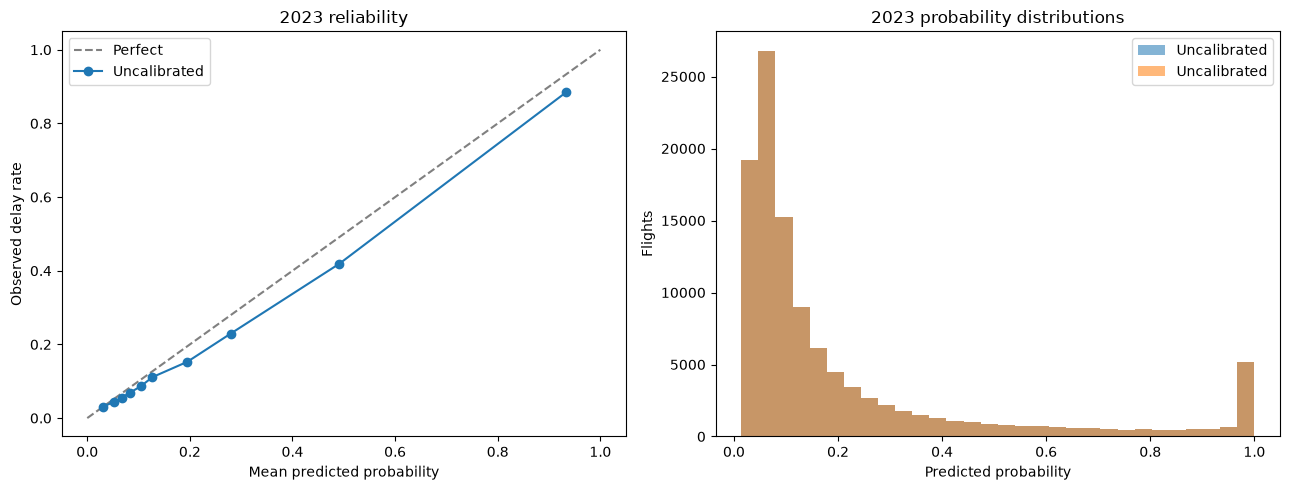

,value
method,Uncalibrated


,value
selected calibration,Uncalibrated
training mean Brier,0.0918
uncalibrated validation AP,0.7526
selected validation AP,0.7526
uncalibrated validation ROC AUC,0.8546
selected validation ROC AUC,0.8546
uncalibrated validation Brier,0.1086
selected validation Brier,0.1086
uncalibrated validation ECE,0.0282
selected validation ECE,0.0282


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
for method, probabilities in dict([
    ("Uncalibrated", raw_validation_probabilities),
    (selected_method, selected_validation_probabilities),
]).items():
    predicted, observed = calibration_curve(y_validation, probabilities, n_bins=10, strategy="quantile")
    axes[0].plot(predicted, observed, marker="o", label=method)
axes[0].set(title="2023 reliability", xlabel="Mean predicted probability", ylabel="Observed delay rate")
axes[0].legend()

axes[1].hist(raw_validation_probabilities, bins=30, alpha=0.55, label="Uncalibrated")
axes[1].hist(selected_validation_probabilities, bins=30, alpha=0.55, label=selected_method)
axes[1].set(title="2023 probability distributions", xlabel="Predicted probability", ylabel="Flights")
axes[1].legend()
fig.tight_layout()
plt.show()

calibrator_description = {"method": selected_method}
if selected_method == "Sigmoid":
    calibrator_description.update({
        "sigmoid slope": float(final_calibrator.coef_[0, 0]),
        "sigmoid intercept": float(final_calibrator.intercept_[0]),
    })
elif selected_method == "Isotonic":
    calibrator_description["isotonic thresholds"] = len(final_calibrator.X_thresholds_)

publishable = pd.Series({
    "selected calibration": selected_method,
    "training mean Brier": float(calibration_summary.iloc[0]["mean_brier_score"]),
    "uncalibrated validation AP": probability_results.loc["Uncalibrated", "average_precision"],
    "selected validation AP": probability_results.loc[selected_method, "average_precision"],
    "uncalibrated validation ROC AUC": probability_results.loc["Uncalibrated", "roc_auc"],
    "selected validation ROC AUC": probability_results.loc[selected_method, "roc_auc"],
    "uncalibrated validation Brier": probability_results.loc["Uncalibrated", "brier_score"],
    "selected validation Brier": probability_results.loc[selected_method, "brier_score"],
    "uncalibrated validation ECE": probability_results.loc["Uncalibrated", "ece_10"],
    "selected validation ECE": probability_results.loc[selected_method, "ece_10"],
}, name="value")
display(pd.Series(calibrator_description, name="value").to_frame())
publishable.to_frame()

## Interpretation checklist

- Select calibration by mean forward-chained 2019 Brier score; 2023 is evaluation only.
- Calibration should improve probability reliability, not create new ranking information. Sigmoid is monotonic, so its AP and ROC AUC should remain essentially unchanged.
- Compare Brier score, log loss, ECE, mean predicted probability, and reliability curves before considering deployment.
- Retain the uncalibrated model if the selected correction does not improve probability quality outside-year enough to justify another fitted stage.
- The final-tail assignment limitation remains, and 2024 remains untouched.